# E-Commerce Product Delivery Prediction

###  PROJECT SUMMARY
My project focuses on predicting product delivery timeliness for an e-commerce company by leveraging robust machine learning models. By analyzing customer behavior and supply chain data, the project aims to accurately forecast whether shipments will arrive on time. These predictive insights will allow the organization to identify key factors affecting delays and optimize their logistical strategies accordingly. Ultimately, this data-driven approach seeks to enhance operational efficiency and boost customer satisfaction through more reliable delivery services.

## Objective
* To develop a robust machine learning classification model that utilizes historical data to predict the probability of a shipment reaching the customer on time.

# IMPORT LIBRARIES 

1. Pandas
Used for loading, cleaning, and manipulating structured data efficiently. It provides DataFrame operations to explore and preprocess the dataset.
2. NumPy
Provides support for fast numerical computations, arrays, and mathematical functions used during data preprocessing and transformations.
3. Matplotlib
A visualization library used to create plots and charts for understanding data patterns, distributions, and trends.
4. Seaborn
Built on Matplotlib, used for creating more attractive and statistical visualizations such as heatmaps, boxplots, and pairplots.
5. Train-Test Split (scikit-learn)
Splits the dataset into training and testing sets to evaluate model performance and prevent overfitting.
6. LabelEncoder
Converts categorical variables into numerical values so machine learning models can interpret them.
7. StandardScaler
Standardizes features by scaling them to mean = 0 and standard deviation = 1, improving model performance for distance-based algorithms like KNN.
8. Logistic Regression
A classification algorithm used to predict binary outcomes by estimating probabilities.
9. Decision Tree Classifier
A tree-based model that splits data into branches based on feature conditions to make predictions.
10. Random Forest Classifier
An ensemble learning method that combines multiple decision trees to improve accuracy and reduce overfitting.
11. K-Nearest Neighbors (KNN)
A distance-based algorithm that classifies new samples based on the closest data points in the training set.
12. Accuracy Score
Measures the percentage of correct predictions made by the model.
13. Classification Report
Provides detailed metrics such as precision, recall, and F1-score to evaluate classification performance.
14. Confusion Matrix
A table that shows correct and incorrect predictions, helping to understand model performance across classes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings 
warnings.filterwarnings('ignore')

##  LOAD DATA

In [2]:
df = pd.read_csv('E_Commerce.csv')

## Data Overview

In [3]:
#Header
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
# Basic Data Inspection
print("Dataset Shape:", df.shape)
print(df.info())
print(df.describe())

Dataset Shape: (10999, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB
None
                ID  Customer_care_calls  Customer_rating  Cost_of_the_Product  \
count  10999.00000         10999.000000   

In [5]:
# Check for Nulls
print("Null Values:\n", df.isnull().sum())


Null Values:
 ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


#### Missing Values

*	The dataset has no missing values, making it clean for modeling.


In [6]:
# Check for Duplicates
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


#### Duplicate Values
*   The dataset has no duplicate values, making it clean for modeling

In [7]:
# Drop ID column
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

#### Dropping Irrelevant Columns:

*    Non-informative columns—such as ID—were removed as they do not contribute to prediction and may introduce noise.


####  The dataset consists of 10,999 observations with 12 features, including:

* Logistics: Warehouse block, Mode of Shipment, Weight.
    
* Customer Interaction: Customer care calls, Rating, Prior purchases.
    
* Product Info: Cost, Importance, Discount offered.
    
* Target: Reached.on.Time_Y.N (1 = Late, 0 = On Time).

# EXPLORATORY DATA ANALYSIS (EDA)

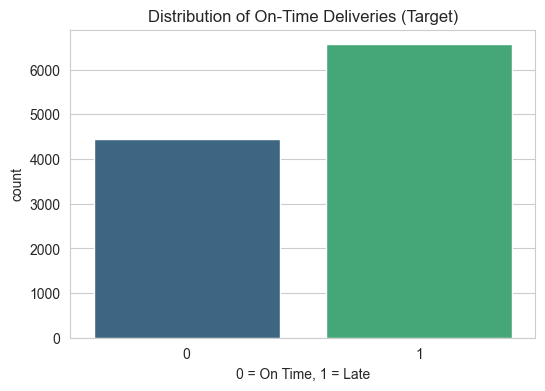

In [8]:
# Set Plot Style
sns.set_style("whitegrid")
# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Reached.on.Time_Y.N', data=df, palette='viridis')
plt.title('Distribution of On-Time Deliveries (Target)')
plt.xlabel('0 = On Time, 1 = Late')
plt.show()

#### Target Variable Distribution (Reached on Time vs Late Delivery)

•The dataset is slightly imbalanced but not extreme.

•Majority of shipments are not delivered on time.

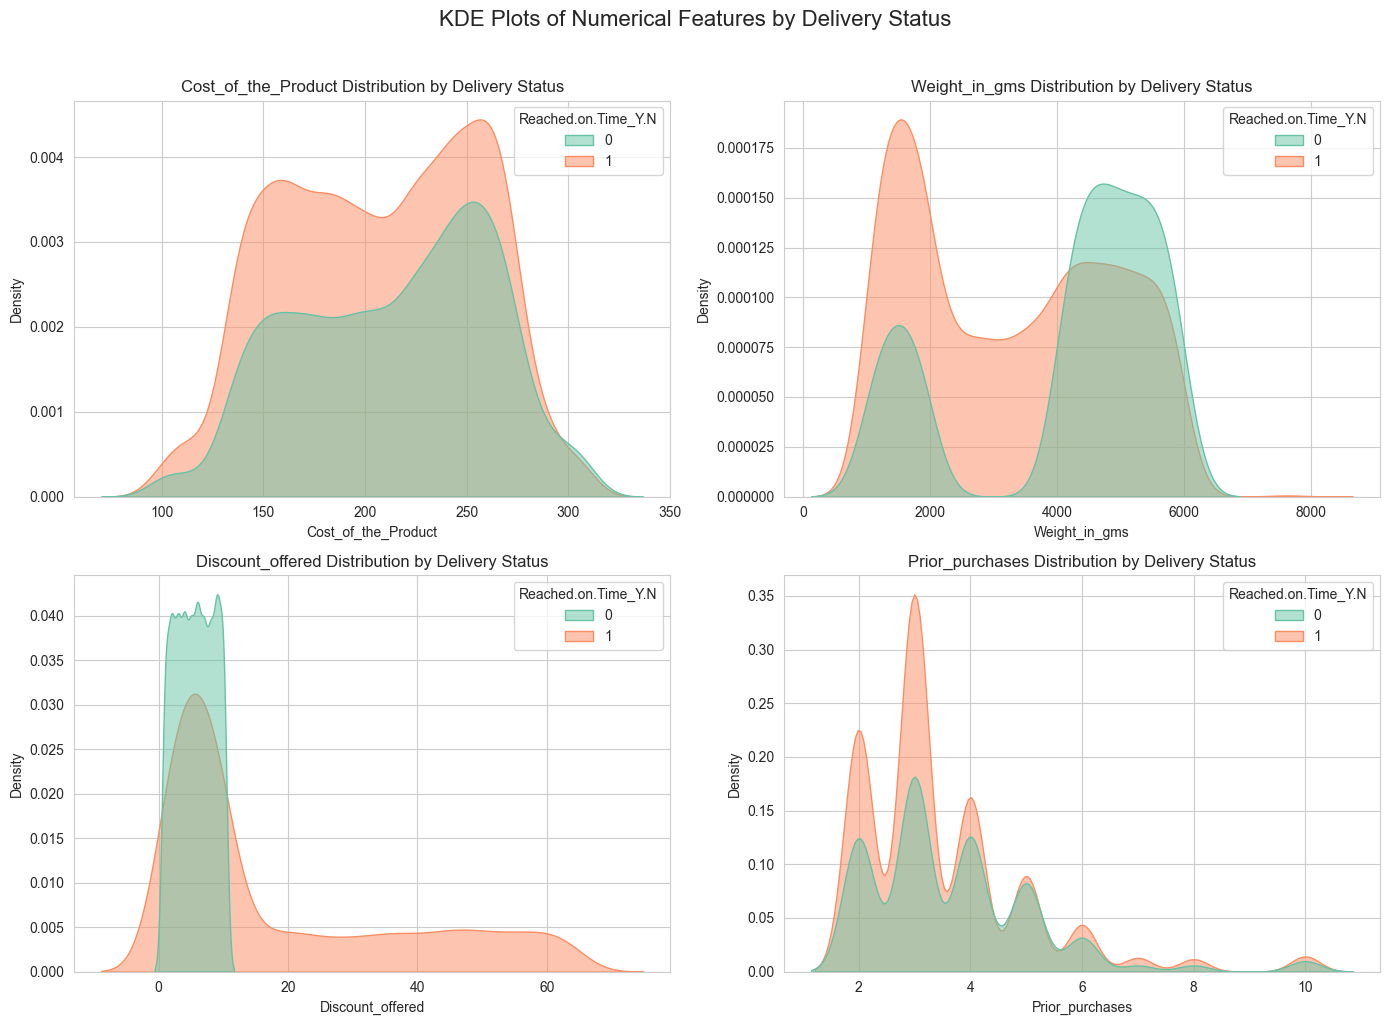

In [9]:
# Numerical Features Distribution
num_cols = ['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered', 'Prior_purchases']
target_col = 'Reached.on.Time_Y.N'
plt.figure(figsize=(14, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(data=df, x=col, hue=target_col, fill=True, alpha=0.5, palette='Set2')
    plt.title(f'{col} Distribution by Delivery Status')
    plt.xlabel(col)
    plt.ylabel('Density')
plt.suptitle('KDE Plots of Numerical Features by Delivery Status', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### Cost of the Product

*   Product prices are spread out across a wide range.

*   Expensive items are usually delivered on time.

#### Product Weight Distribution

*   Product weights fall into different groups 

*   Items heavier than 4,000 grams are more likely to be delayed.

#### Discounts Offered

*   The data is **heavily right-skewed**, meaning most shipments receive little to no discount (clustered between 0-10%).

*   Large discounts are rare "outlier" events. However, these high-discount items are strongly correlated with late              deliveries.

#### Prior Purchases

*   Most customers are new or have bought only a few items (2–3).


*   Loyal customers (those with many past purchases) are fewer. Delivery speed looks similar for both new and repeat buyers.

#### Outlier Analysis

*	Some unusual values exist in weight and discount.

*	These unusual cases should not be removed because they give important clues about delivery delays.

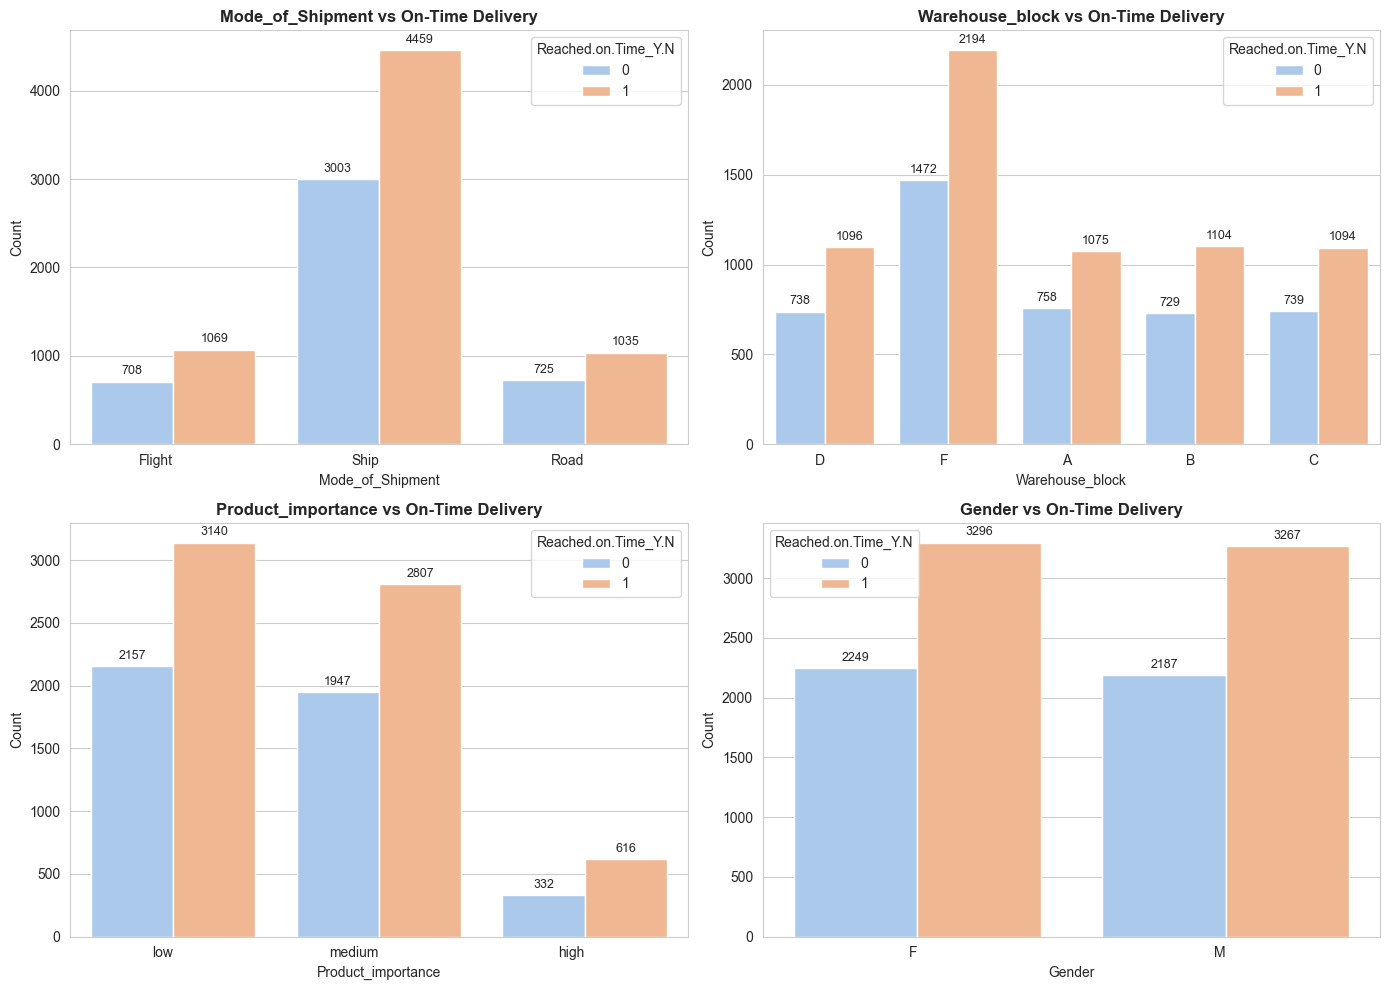

In [10]:
#  Categorical Features vs Target
cat_cols = ['Mode_of_Shipment', 'Warehouse_block', 'Product_importance', 'Gender']
plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    ax = sns.countplot(data=df, x=col, hue='Reached.on.Time_Y.N', palette='pastel')
    plt.title(f'{col} vs On-Time Delivery', fontsize=12, fontweight='bold')
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
    plt.xticks(rotation=0, ha='right')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Shipment Mode Analysis

*	Road and Ship modes demonstrate higher proportions of on-time deliveries

*	Flight shipment shows the highest share of late deliveries.

#### Warehouse Block Performance

*	Blocks A, B, C, and D have balanced data.

*	Block A and C usually have better on-time delivery.

*   Block B has more late delivery proportion than other blocks.

#### Product Importance

*	“High importance” products surprisingly still face delays.

*	“Low importance” items show delays but have more variability.

#### Gender

*   Both genders show similar on-time delivery percentages.

*   There is no strong evidence that gender influences whether a delivery reaches on time.

*   Any difference observed is usually very small.

*   Male and female customers both experience late deliveries at nearly equal rates.

*   No gender-specific pattern is visible for late deliveries.

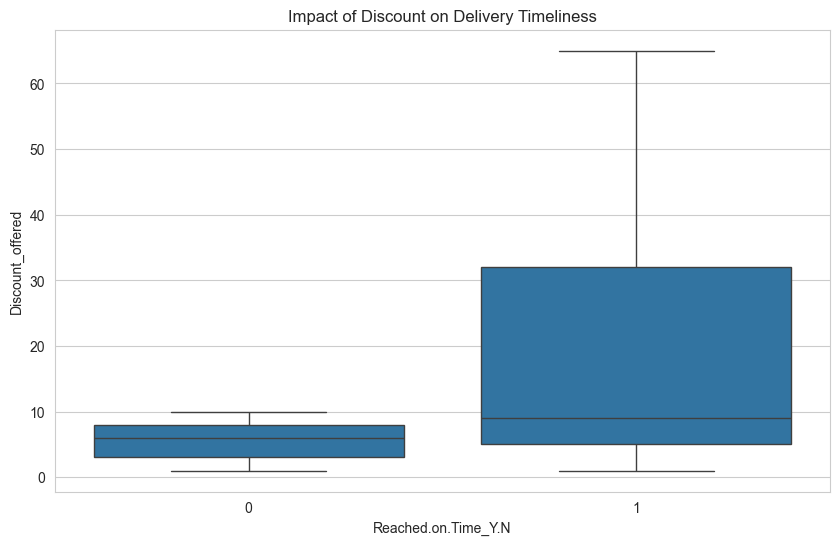

In [11]:
#  Impact of Discount on Delivery Time
plt.figure(figsize=(10, 6))
sns.boxplot(x='Reached.on.Time_Y.N', y='Discount_offered', data=df)
plt.title('Impact of Discount on Delivery Timeliness')
plt.show()

#### Impact of Discount on Delivery Timeliness

*   Late deliveries tend to have slightly higher discount values compared to on-time deliveries, as seen by the higher           median in the late-delivery box.

*   On-time deliveries show more tightly packed discount values, indicating more consistent pricing/discounting.


*   Some high-discount outliers appear mostly in the late-delivery category, possibly hinting that heavy discounts may be        associated with operational strain.

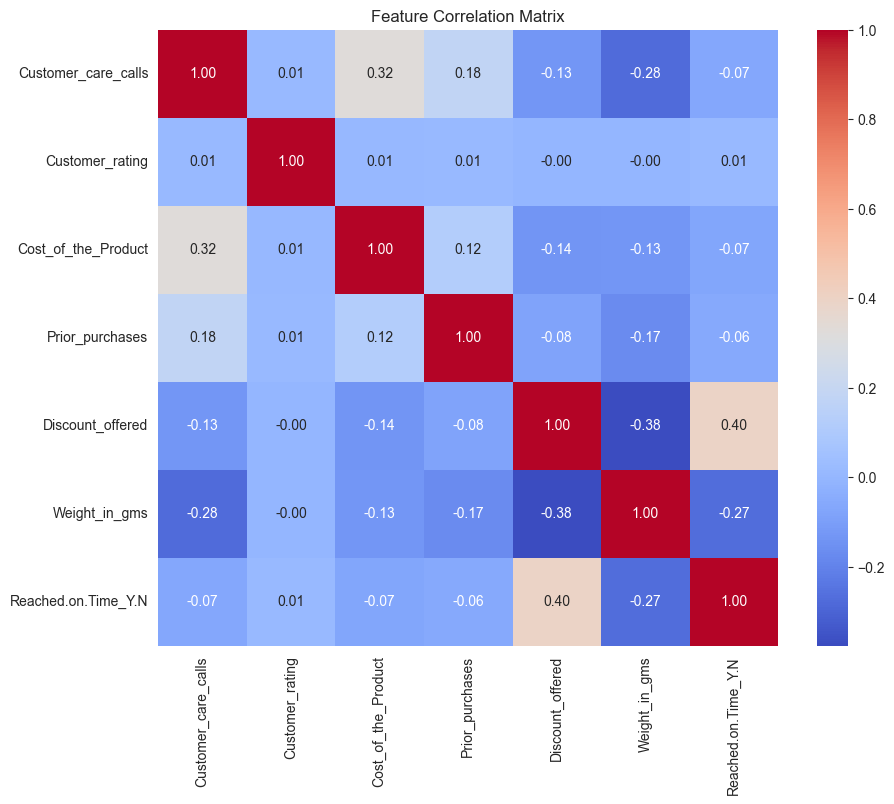

In [12]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

#### Correlation Heatmap Insights

*	Discount_offered exhibits the strongest positive correlation with Reached.on.Time_Y.N

*	There is a positive correlation between Cost_of_the_Product and Customer_care_calls.

*   Aside from specific pairings, the correlation values between most independent features are low .

# DATA PREPROCESSING & FEATURE ENGINEERING
 Data preprocessing and feature engineering ensure that the dataset is clean, consistent, and suitable for machine learning models. These steps handle missing values, encode categorical variables, scale numerical features, and create meaningful representations of data. By improving data quality and enhancing feature usefulness, preprocessing helps models learn more effectively and produce accurate, reliable predictions

In [13]:
# Encoding Categorical Variables
# Label Encoding for ordinal (Product_importance)
le = LabelEncoder()
df['Product_importance'] = le.fit_transform(df['Product_importance']) # low:0, medium:2, high:1 (approx)
df['Gender'] = le.fit_transform(df['Gender']) # F:0, M:1

# One-Hot Encoding for nominal (Warehouse, Shipment)
df = pd.get_dummies(df,columns=['Warehouse_block', 'Mode_of_Shipment'], drop_first=True)

# Splitting Data
X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling Data (Important for KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Encoding Categorical Variables:
Non-numeric columns such as product importance and gender were transformed using Label Encoding and Warehouse_block and  Mode_of_Shipment were transformed using One-Hot Encoding for model compatibility.

#### Dataset Balancing & Splitting:
The data was checked for imbalance and then split into training and testing sets to prepare for model building(For KNN and Logistic Regression).

#### Feature Scaling:
Numerical features with wide value ranges were scaled (using StandardScaler) to improve model stability and convergence.

# MODEL BUILDING AND COMPARISON

## 1. Logistic Regression
Logistic Regression is a basic method used to predict two possible outcomes, like whether a shipment will be on time or late.
## 2. Decision Tree Classifier
A Decision Tree works like a flowchart. It asks a series of yes/no questions about a shipment (like weight or distance) and then decides whether it will be on time or late. 
## 3. Random Forest Classifier
Random Forest is a method that builds many decision trees instead of just one. Each tree makes a prediction, and the final result is decided by the majority vote of all the trees. 
## 4. K-Nearest Neighbors (KNN)
KNN is a method that predicts whether a shipment will be on time or late by comparing it to past shipments.

Model Evaluation Results:

--- Logistic Regression ---
Accuracy: 0.6341
              precision    recall  f1-score   support

           0       0.55      0.55      0.55       895
           1       0.69      0.69      0.69      1305

    accuracy                           0.63      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.63      0.63      0.63      2200

Confusion Matrix:
 [[492 403]
 [402 903]]


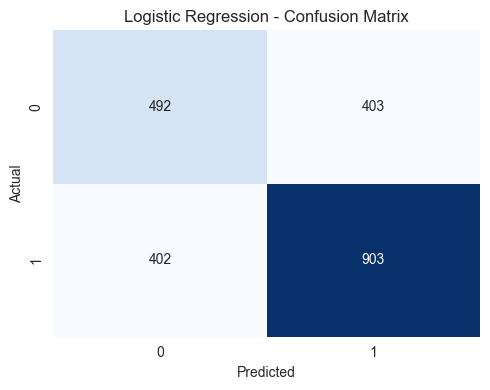

------------------------------
--- Decision Tree ---
Accuracy: 0.6314
              precision    recall  f1-score   support

           0       0.55      0.54      0.54       895
           1       0.69      0.69      0.69      1305

    accuracy                           0.63      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.63      0.63      0.63      2200

Confusion Matrix:
 [[484 411]
 [400 905]]


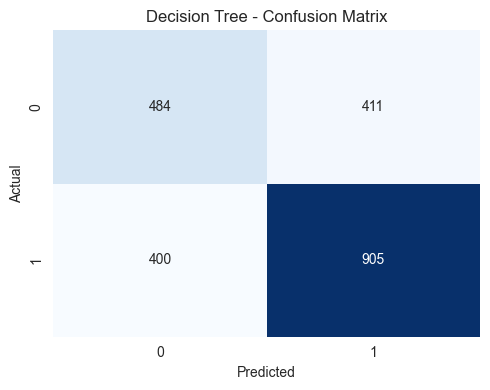

------------------------------
--- Random Forest ---
Accuracy: 0.6618
              precision    recall  f1-score   support

           0       0.57      0.69      0.62       895
           1       0.75      0.64      0.69      1305

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.66      0.66      2200

Confusion Matrix:
 [[619 276]
 [468 837]]


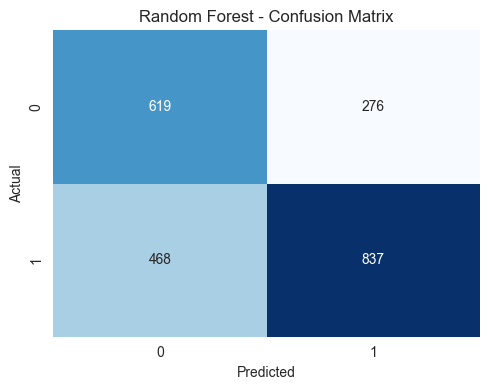

------------------------------
--- KNN ---
Accuracy: 0.6345
              precision    recall  f1-score   support

           0       0.55      0.59      0.57       895
           1       0.70      0.67      0.68      1305

    accuracy                           0.63      2200
   macro avg       0.62      0.63      0.63      2200
weighted avg       0.64      0.63      0.64      2200

Confusion Matrix:
 [[524 371]
 [433 872]]


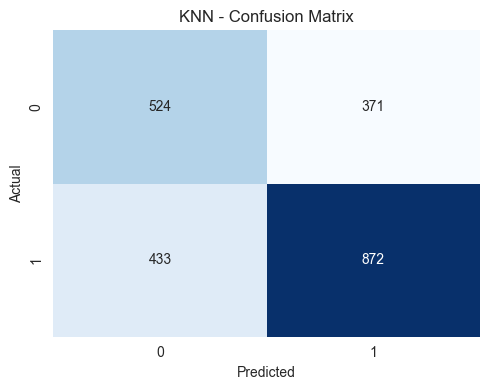

------------------------------


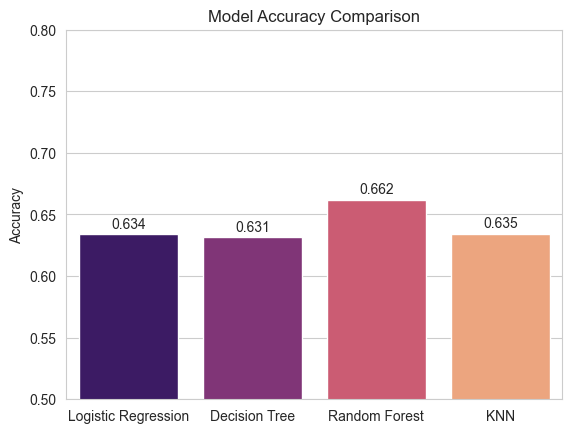

In [14]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

print("Model Evaluation Results:\n")

for name, model in models.items():
    # Train
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    # Classification report
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    print("Confusion Matrix:\n", cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    print("-" * 30)
# Comparison Barchart Plot
ax = sns.barplot(x=list(results.keys()), y=list(results.values()), palette='magma')
plt.ylim(0.5, 0.8)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(list(results.values())):
    ax.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()

#### Observation(Model Comparison)
* Multiple models were trained (Logistic Regression, Decision Tree, Random Forest, KNN) to identify the best-            performing algorithm for the prediction task.

* Each model was evaluated using consistent metrics such as accuracy, precision ansd recall to ensure fair comparison. 

* Random Forest and tree-based models generally performed better, indicating that the dataset benefits from models that        capture non-linear patterns.

* Simpler models like Logistic Regression performed adequately, but showed lower accuracy due to limited ability to handle     complex feature interactions.
 
* KNN results depended heavily on scaling and showed moderate performance, highlighting the importance of preprocessing.

### Model Performance:
We evaluated four algorithms: Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Random Forest.
Winner: Random Forest Classifier. It handled the non-linear relationships between weight and discounts best.
Metrics: Accuracy: 66%, F1-Score: 0.69.

# 5.FEATURE IMPORTANCE OF BEST MODEL

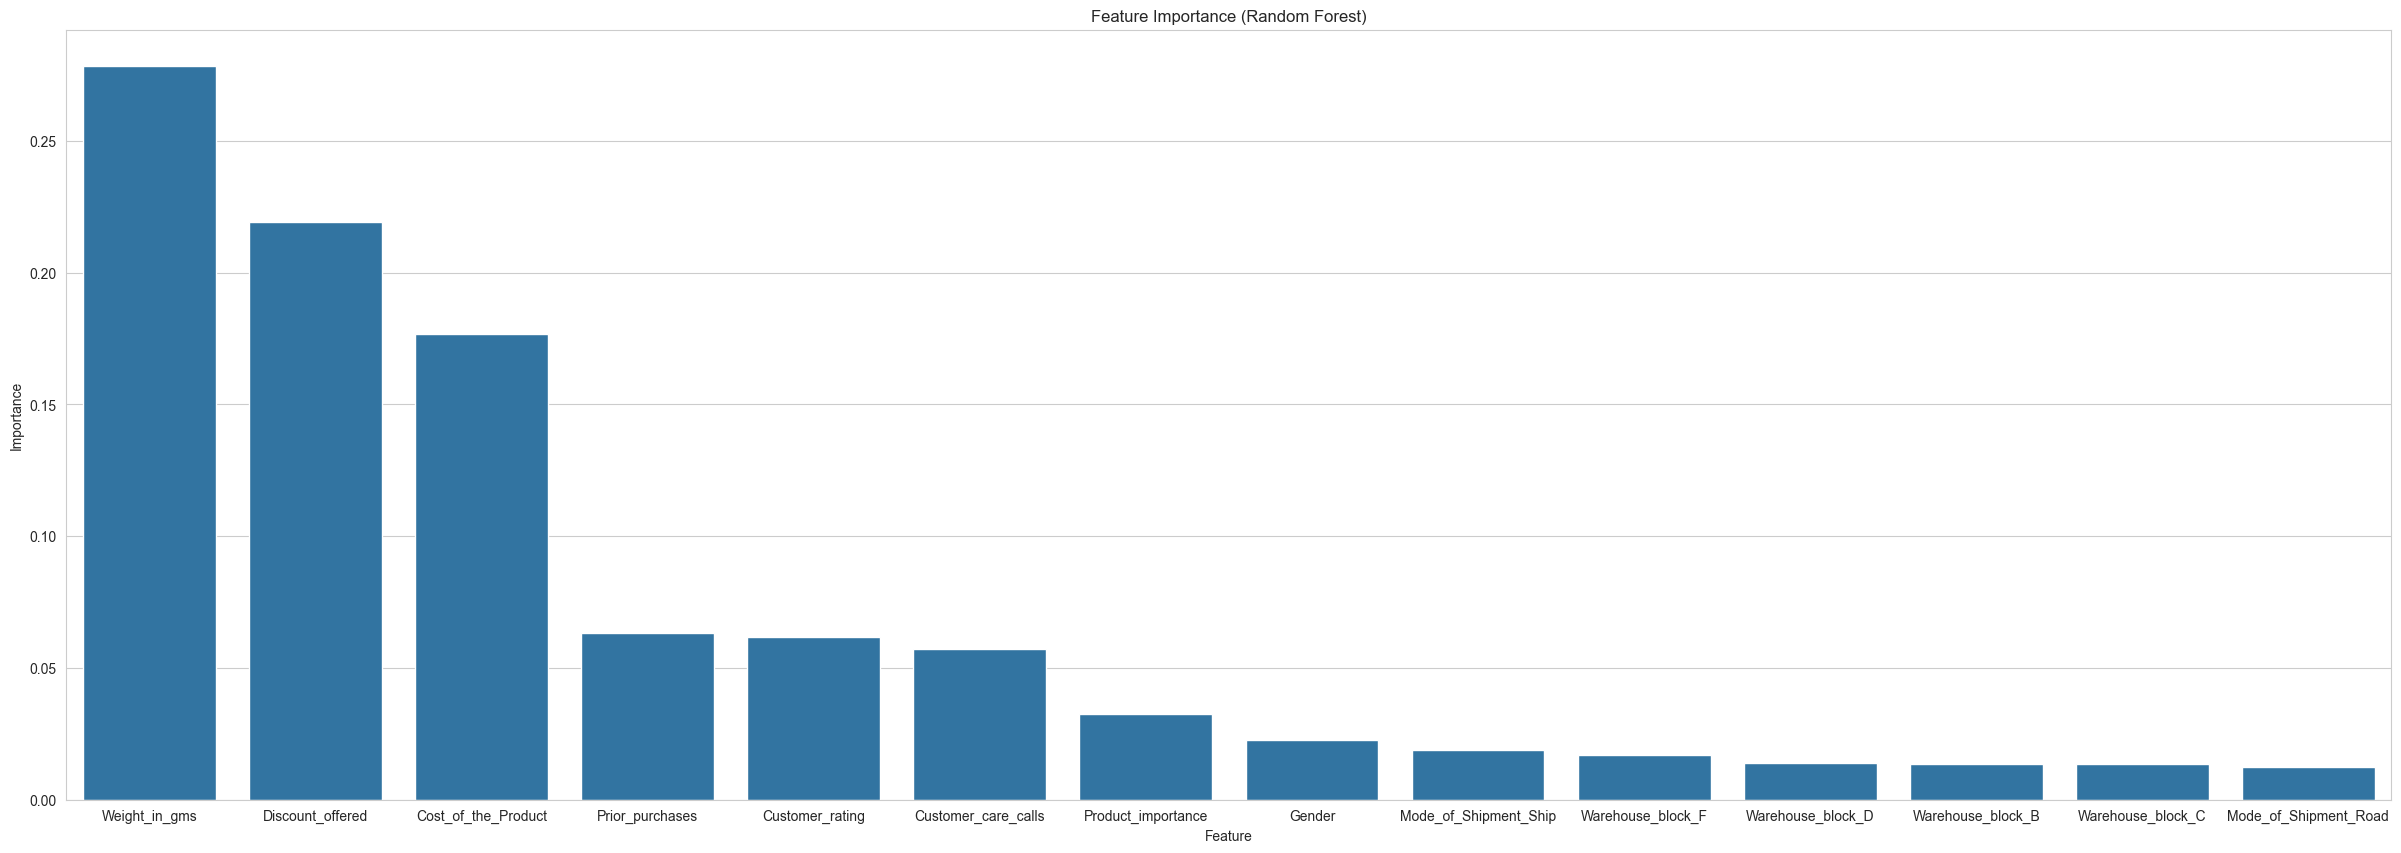

In [15]:
# Feature Importance (Random Forest)
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(30, 10))
sns.barplot(x='Feature', y='Importance', data=feat_imp_df)
plt.title('Feature Importance (Random Forest)')
plt.show()

#### Observation(Feature Importance)
*  The Model Accuracy Comparison bar chart clearly indicates that the Random Forest Classifier outperforms the                  other algorithms (Logistic Regression, Decision Tree, and KNN) with an accuracy of approximately 66%, compared to 63% for    the others.
*  The Feature Importance plot reveals that Discount_offered is by far the most significant factor in predicting delivery       delays. This suggests a strong correlation between promotional items and logistics constraints.
*  Physical and monetary attributes (Weight_in_gms, Cost_of_the_Product) are highly influential, whereas features like          Gender, Warehouse_block, and Mode_of_Shipment have minimal impact on the model's  predictions.
*  Prior_purchases and Customer_care_calls appear in the middle of the importance ranking, indicating that customer             interaction history plays a moderate role in predicting whether a shipment will arrive on time. 

# Recommendations
*  High Importance Products: Even though these items are marked as “high importance,” they often get delayed. This could be     because extra security checks or special handling slow them down. The company should investigate why this happens.

*  Discount Strategy: Shipments with big discounts are more likely to be late. To avoid this, don’t give high discounts on      shipments that are already risky — like heavy items sent by air.

*  Shipment Mode: Air shipments (“Flight”) have the most delays. For items that aren’t urgent, especially heavy or              discounted ones, use road or ship transport instead. This will cut costs and improve reliability.